### 3.5 Neural network - feedforward baseline

The procedure of the SVM subsections is repeated with a feedforward neural network. Required outputs:

- Reuse of the same feature matrix, splits, scaling, and metrics from 3.1-3.2 so that the later comparison is fair.
- A feedforward multilayer perceptron: an input layer sized to the feature count, several hidden layers with non-linear activations, and a single linear output for the demand regression.
- Training with early stopping on the validation fold, and MAE, RMSE, and R2 on the holdout.
- A statement of the loss, optimiser, and stopping criterion and the reasons for their selection.

In [23]:
# Shared helpers needed for Section 3.7

TEST_FRACTION = 0.15

WEATHER_COLS = [
    "temp_4h",
    "rain_4h",
    "snow_4h",
    "precip_4h",
    "wind_speed_4h",
    "weather_code_4h",
]

CHICAGO_CENTER = (41.8781, -87.6298)


def _cyclical(values, period):
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)


def _h3_centroids(cell_ids):
    try:
        from h3 import cell_to_latlng as to_geo
    except ImportError:
        from h3 import h3_to_geo as to_geo

    coords = {c: to_geo(c) for c in pd.unique(cell_ids)}

    lat = cell_ids.map(lambda c: coords[c][0]).astype("float64")
    lon = cell_ids.map(lambda c: coords[c][1]).astype("float64")

    return lat, lon


def _haversine_km(lat1, lon1, lat2, lon2):
    r = 3959.0

    p1 = np.radians(lat1)
    p2 = np.radians(lat2)

    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)

    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    )

    return 2 * r * np.arcsin(np.sqrt(a))


def detect_hotspot_anchors(train_panel, centroid_fn=_h3_centroids, n_candidates=8):
    tot = (
        train_panel
        .groupby("location_id")["demand_count"]
        .sum()
        .sort_values(ascending=False)
    )

    cand = list(tot.index[:n_candidates])

    lat, lon = centroid_fn(pd.Series(cand))
    cent = {c: (la, lo) for c, la, lo in zip(cand, lat, lon)}

    chosen = [cand[0]]

    while len(chosen) < 3:
        nxt = max(
            (c for c in cand if c not in chosen),
            key=lambda c: min(
                _haversine_km(*cent[c], *cent[s])
                for s in chosen
            ),
        )
        chosen.append(nxt)

    loop = min(
        chosen,
        key=lambda c: _haversine_km(*cent[c], *CHICAGO_CENTER),
    )

    rest = sorted(
        [c for c in chosen if c != loop],
        key=lambda c: cent[c][0],
        reverse=True,
    )

    return {
        "loop": loop,
        "ohare": rest[0],
        "midway": rest[1],
    }


def build_features(panel, anchors, centroid_fn=_h3_centroids):
    d = panel.copy()

    y = d["demand_count"].astype("float64")
    ts = d["timestamp"]

    feats = {}

    feats["hour_sin"], feats["hour_cos"] = _cyclical(ts.dt.hour, 24)
    feats["dow_sin"], feats["dow_cos"] = _cyclical(ts.dt.dayofweek, 7)
    feats["month_sin"], feats["month_cos"] = _cyclical(ts.dt.month - 1, 12)
    feats["is_weekend"] = (ts.dt.dayofweek >= 5).astype("int64")

    lat, lon = centroid_fn(d["location_id"])

    feats["cell_lat"] = lat
    feats["cell_lon"] = lon

    for name, cell in anchors.items():
        a_lat, a_lon = centroid_fn(pd.Series([cell]))

        feats[f"dist_to_{name}_mi"] = _haversine_km(
            lat,
            lon,
            a_lat.iloc[0],
            a_lon.iloc[0],
        )

    X = pd.DataFrame(feats, index=d.index)
    X = pd.concat([X, d[WEATHER_COLS].astype("float64")], axis=1)

    return X, y, list(X.columns)

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROCESSED = pathlib.Path("../processed")

RANDOM_STATE = 42
N_CV_SPLITS = 5

X_dev = pd.read_parquet(PROCESSED / "task3_X_dev.parquet")
X_test = pd.read_parquet(PROCESSED / "task3_X_test.parquet")

y_dev = pd.read_parquet(PROCESSED / "task3_y_dev.parquet")["demand_count"]
y_test = pd.read_parquet(PROCESSED / "task3_y_test.parquet")["demand_count"]

test_panel = pd.read_parquet(PROCESSED / "task3_test_panel.parquet")
groups_dev = pd.read_parquet(PROCESSED / "task3_groups_dev.parquet")["day"].values
cv = GroupKFold(n_splits=N_CV_SPLITS)

feature_names = X_dev.columns.tolist()


def make_estimator(model):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)


def evaluate(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

In [2]:
import pathlib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_validate, ParameterGrid
from sklearn.utils.validation import check_is_fitted
import shap
import matplotlib.gridspec as gridspec

In [3]:
# Pytorch architecture: simple feedforward net with two hidden layers, ReLU activations, and dropout.
class _PytorchModel(nn.Module):
    def __init__(self, n_features: int, hidden_sizes: tuple, dropout: float, activation=nn.ReLU):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(activation())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

In [4]:
# Sklearn-compatible wrapper around the Pytorch model
class PytorchRegressor(BaseEstimator, RegressorMixin):
    """
    Inherits BaseEstimator  -> get_params/set_params -> GridSearchCV / ParameterGrid work.
    Inherits RegressorMixin -> score() and regressor tagging for Pipeline / cross_validate.
        Parameters
    ----------
    hidden_sizes  : tuple of ints   widths of hidden layers
    dropout       : float           dropout probability (0 = disabled)
    lr            : float           Adam learning rate
    batch_size    : int
    max_epochs    : int             upper bound; early stopping may halt sooner
    patience      : int             early-stopping patience (epochs without val improvement)
    val_fraction  : float           share of each training batch used for early stopping. For example, 0.15 means 85% of training data is used for training and 15% tells it when to stop.
    """
    
    def __init__(
            self,
            hidden_sizes=(64, 32),
            dropout=0.2,
            lr=1e-3,
            batch_size=25,
            max_epochs=20,
            patience=15,
            val_fraction=0.15,
            random_state=42):
        self.hidden_sizes = hidden_sizes
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.val_fraction = val_fraction
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)

        X_arr = np.asarray(X, dtype=np.float32)
        y_arr = np.asarray(y, dtype=np.float32) 

        # Internal val split for early stopping
        n_val = max(1, int(len(X_arr) * self.val_fraction))
        idx   = np.random.permutation(len(X_arr))
        X_tr, y_tr = X_arr[idx[n_val:]], y_arr[idx[n_val:]]
        X_vl, y_vl = X_arr[idx[:n_val]], y_arr[idx[:n_val]]

        train_loader = DataLoader(
            TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
            batch_size=self.batch_size, shuffle=True,
        )


        self.model_ = _PytorchModel(n_features=X.shape[1], hidden_sizes=self.hidden_sizes,
                                   dropout=self.dropout).to("cpu")
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion     = nn.MSELoss()
        X_vl_t        = torch.from_numpy(X_vl)
        y_vl_t        = torch.from_numpy(y_vl)

        best_val      = float("inf")
        no_improve    = 0
        self.train_losses_ = []
        self.val_losses_   = []
        self.best_epoch_   = 0

        for epoch in range(self.max_epochs):
            # training step
            self.model_.train()
            epoch_loss = 0
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                preds = self.model_(X_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()*len(X_batch)
            self.train_losses_.append(epoch_loss / len(X_tr))

            # validation step
            self.model_.eval()
            with torch.no_grad():
                val_loss = criterion(self.model_(X_vl_t), y_vl_t).item()
            self.val_losses_.append(val_loss)

            # early stopping: save best weights
            if val_loss < best_val - 1e-6:
                best_val           = val_loss
                no_improve         = 0
                self.best_epoch_   = epoch
                self._best_state   = {k: v.clone() for k, v in self.model_.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= self.patience:
                    break

        self.model_.load_state_dict(self._best_state)   # restore best weights
        self.n_features_in_ = X_arr.shape[1]
        return self

    def predict(self, X):
        self.model_.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(np.asarray(X, dtype=np.float32))
            preds = self.model_(X_tensor).cpu().numpy()
        return preds
    
    def get_loss_history(self):
        """Return (train_losses, val_losses, best_epoch) for plotting."""
        check_is_fitted(self, "train_losses_")
        return self.train_losses_, self.val_losses_, self.best_epoch_

In [5]:
# --- Baseline architecture:
# Input -> ReLU(64) + Dropout -> ReLU(32) + Dropout -> Linear(1)
nn_baseline_est = make_estimator(PytorchRegressor(
    hidden_sizes = (64, 32),
    dropout      = 0.2,
    lr           = 1e-3,
    batch_size   = 512,
    max_epochs   = 150,
    patience     = 15,
    val_fraction = 0.1,
    random_state=RANDOM_STATE))

cv_res_base = cross_validate(
    nn_baseline_est, X_dev, y_dev,
    groups             = groups_dev,
    cv                 = cv,
    scoring            = {
        "MAE":  "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2":   "r2",
    },
    return_train_score = True,
    n_jobs             = 1,      # PyTorch + forked workers can deadlock; keep sequential
)

print(f"Baseline CV  (GroupKFold 5-fold):")
print(f"  MAE  : {-cv_res_base['test_MAE'].mean():.4f}  ±  {cv_res_base['test_MAE'].std():.4f}")
print(f"  RMSE : {-cv_res_base['test_RMSE'].mean():.4f}  ±  {cv_res_base['test_RMSE'].std():.4f}")
print(f"  R²   : { cv_res_base['test_R2'].mean():.4f}  ±  {cv_res_base['test_R2'].std():.4f}")


Baseline CV  (GroupKFold 5-fold):
  MAE  : 29.2446  ±  1.5277
  RMSE : 110.7708  ±  6.9129
  R²   : 0.8984  ±  0.0142


In [6]:
# Fit on full dev set and evaluate on test set
nn_baseline_est.fit(X_dev, y_dev)
y_pred_nn_baseline = nn_baseline_est.predict(X_test)
metrics_nn_baseline = evaluate(y_test, y_pred_nn_baseline)

print("Baseline test set performance:")
for metric, value in metrics_nn_baseline.items():
    print(f"  {metric}: {value:.4f}")   

Baseline test set performance:
  MAE: 25.9855
  RMSE: 92.8705
  R2: 0.9236


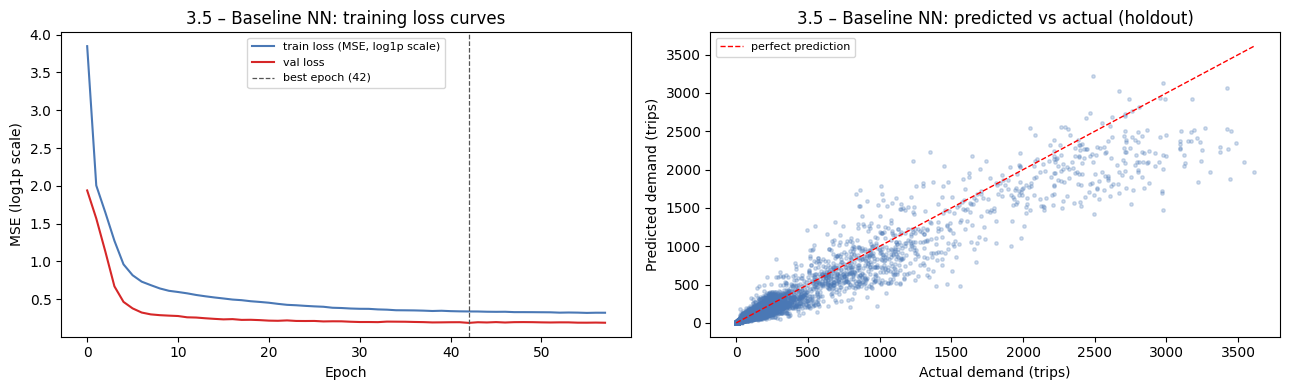

In [7]:
# --- 3.5c  Loss curves + predicted vs actual ---
inner_model = nn_baseline_est.regressor_.named_steps["model"]
tr_loss, vl_loss, best_ep = inner_model.get_loss_history()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# loss curves
ax = axes[0]
ax.plot(tr_loss, label="train loss (MSE, log1p scale)", color="#4a78b5")
ax.plot(vl_loss, label="val loss",                      color="#d62728")
ax.axvline(best_ep, color="#555", linestyle="--", linewidth=0.9,
           label=f"best epoch ({best_ep})")
ax.set(xlabel="Epoch", ylabel="MSE (log1p scale)",
       title="3.5 – Baseline NN: training loss curves")
ax.legend(fontsize=8)

# predicted vs actual
ax = axes[1]
y_pred_clipped = np.clip(y_pred_nn_baseline, 0, None)
ax.scatter(y_test, y_pred_clipped, alpha=0.25, s=6, color="#4a78b5")
lim = max(y_test.max(), y_pred_clipped.max())
ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="perfect prediction")
ax.set(xlabel="Actual demand (trips)", ylabel="Predicted demand (trips)",
       title="3.5 – Baseline NN: predicted vs actual (holdout)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Baseline architecture**: Two hidden layers. Layer 1 has 64 nodes, layer 2 has 32 nodes. The model uses ReLU as activation function, and dropout = 0.2 - it means that in each running, model omits 20% nodes in the hidden layers. It can reduce the interaction between some high-correlated nodes and make sure model does not extremely depend on some specific parameter.

**Loss function.** MSE on the log1p-scaled target. Because `make_estimator` wraps the  
network inside `TransformedTargetRegressor`, the PyTorch model always trains on  
log1p(demand) and predictions are automatically inverted via expm1 before `evaluate()`.

**Optimiser.** Adam with lr=1e-3.

**Early stopping.** Patience=15 epochs on an internal 10 % validation split drawn from the training fold. This prevents overfitting without requiring a fixed epoch budget, and the best weights are restored before the model is returned. The internal val_faction split used for early stopping. It means that we use a part of training dataset to train, and the internal validation part to tell the model when to stop. This internal validation fold does not overlap with the outer test fold or the final holdout.



**Hand-off to 3.8.**  
The following variables are consumed by section 3.8:

| Variable | Content |
|---|---|
| `nn_baseline_est` | Fitted estimator (scaler + base PyTorch model + log1p wrapper) of baseline Neural Network model|
| `metrics_nn_baseline` | `{"MAE": ..., "RMSE": ..., "R2": ...}` on holdout |
| `y_pred_nn_baseline` | Predicted demand in test dataset |

### 3.6 Neural network - tuning

Required outputs:

- Exploration of architecture and regularisation: number and width of layers, dropout, learning rate, batch size, and epochs.
- All tuning confined to the training and validation folds, with a single final holdout evaluation.
- The resulting holdout metrics recorded for the comparison in 3.8, alongside a note on whether performance differs materially from the SVM.

In [8]:
# Tuning the baseline architecture with manual grid search
# Parameters to tune:
# - hidden_sizes: architecture depth and width
# - dropout: regularisation strength
# - lr: learning rate
# - batch_size: training batch size
PARAM_GRID = list(ParameterGrid({
    "hidden_sizes" : [(64, 32), (128, 64, 32)],
    "dropout"      : [0.1, 0.2],
    "lr"           : [1e-3, 5e-4],
    "batch_size"   : [256, 512],
}))

result = []

for i, params in enumerate(PARAM_GRID):
    print(f"Running config {i+1}/{len(PARAM_GRID)}: {params}")
    est = make_estimator(PytorchRegressor(**params))
    cv_res = cross_validate(
        est, X_dev, y_dev,
        groups             = groups_dev,
        cv                 = cv,
        scoring            = "neg_mean_absolute_error",
        return_train_score = False,
        n_jobs             = 1,
    )
    mean_mae = -cv_res["test_score"].mean()
    std_mae  = cv_res["test_score"].std()
    print(f"  MAE: {mean_mae:.4f} ± {std_mae:.4f}")
    result.append({"params": params, "MAE_mean": mean_mae, "MAE_std": std_mae})

Running config 1/16: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64, 32), 'lr': 0.001}
  MAE: 28.6767 ± 0.4018
Running config 2/16: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64, 32), 'lr': 0.0005}
  MAE: 30.0707 ± 0.4659
Running config 3/16: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (128, 64, 32), 'lr': 0.001}
  MAE: 25.1975 ± 0.6332
Running config 4/16: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (128, 64, 32), 'lr': 0.0005}
  MAE: 26.7229 ± 1.1930
Running config 5/16: {'batch_size': 256, 'dropout': 0.2, 'hidden_sizes': (64, 32), 'lr': 0.001}
  MAE: 33.0685 ± 1.4655
Running config 6/16: {'batch_size': 256, 'dropout': 0.2, 'hidden_sizes': (64, 32), 'lr': 0.0005}
  MAE: 36.8522 ± 0.6067
Running config 7/16: {'batch_size': 256, 'dropout': 0.2, 'hidden_sizes': (128, 64, 32), 'lr': 0.001}
  MAE: 26.2151 ± 0.7729
Running config 8/16: {'batch_size': 256, 'dropout': 0.2, 'hidden_sizes': (128, 64, 32), 'lr': 0.0005}
  MAE: 29.9106 ± 2.8031
Running config 9

In [9]:
# Refit the best model on the full dev set and evaluate on the test set
best_params = min(result, key=lambda x: x["MAE_mean"])["params"]

print("Best hyperparameters:", best_params)
best_est = make_estimator(PytorchRegressor(**best_params))
best_est.fit(X_dev, y_dev)
y_pred_best = best_est.predict(X_test)
metrics_best = evaluate(y_test, y_pred_best)
print("Best model test set performance:")
for metric, value in metrics_best.items():
    print(f"  {metric}: {value:.4f}")   

Best hyperparameters: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (128, 64, 32), 'lr': 0.001}
Best model test set performance:
  MAE: 22.8896
  RMSE: 86.4569
  R2: 0.9338


In [10]:
demand_all = pd.concat([y_dev, y_test])

print(demand_all.describe())
print(f"% zeros: {(demand_all == 0).mean() * 100:.1f}%")

count    133029.000000
mean        108.118245
std         346.661425
min           0.000000
25%           3.000000
50%          11.000000
75%          52.000000
max        4098.000000
Name: demand_count, dtype: float64
% zeros: 12.6%


**The best model**: 
- The average `demand_count` of the dataset is 108. The MAE of the best model is 22, which is only 20% of average. It indicates that model is quite good in predicting the demand.
- RMSE is much more larger than MAE. It may be because the model makes huge mistakes with the spatial unit that have very high demand.
- R2 = 93.54. It means that model can explain 93.54% of variance. In other word, it shows that model is 93.54% than the model predicts all rows as mean of demand

C:\Users\Georg\AppData\Local\Temp\ipykernel_2156\852343366.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


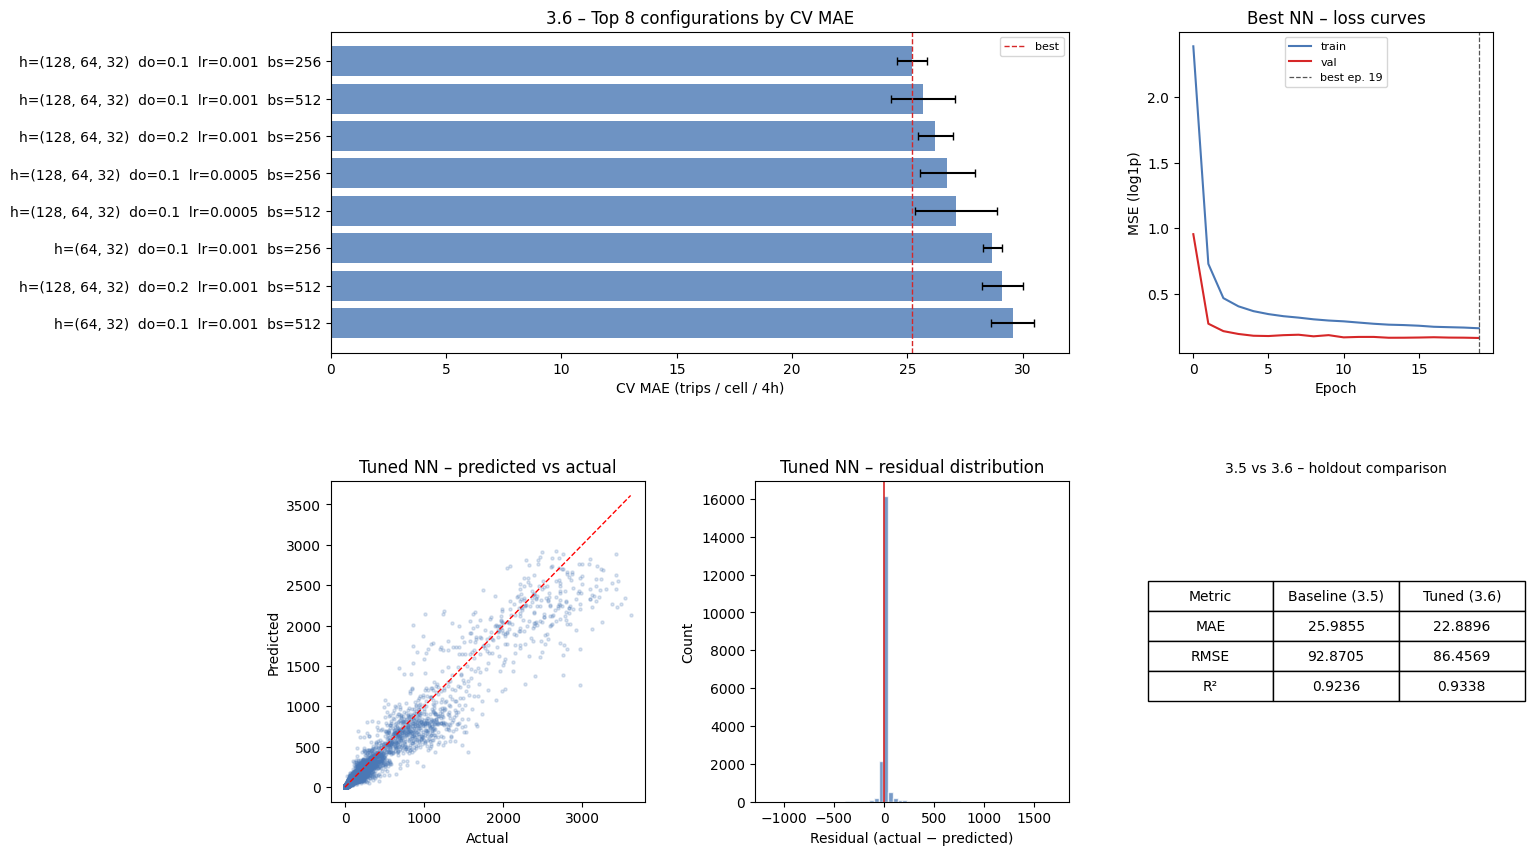

In [11]:
# Visualise the best model's predictions vs actuals
result_df = pd.DataFrame(result).sort_values('MAE_mean').reset_index(drop=True)
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# (a) CV MAE bar chart – top 8 configurations
ax0 = fig.add_subplot(gs[0, :2])
top8 = result_df.head(8).copy()
top8["label"] = [
    f"h={r.get('hidden_sizes')}  do={r.get('dropout')}  lr={r.get('lr')}  bs={int(r.get('batch_size'))}"
    for r in top8.params
]
ax0.barh(top8["label"][::-1], top8["MAE_mean"][::-1],
         xerr=top8["MAE_std"][::-1],
         color="#4a78b5", alpha=0.8, capsize=3)
ax0.axvline(result_df.iloc[0]["MAE_mean"], color="#d62728",
            linestyle="--", linewidth=1, label="best")
ax0.set(xlabel="CV MAE (trips / cell / 4h)",
        title="3.6 – Top 8 configurations by CV MAE")
ax0.legend(fontsize=8)

# (b) Loss curves of the best model
ax1 = fig.add_subplot(gs[0, 2])
inner_best = best_est.regressor_.named_steps["model"]
tr_b, vl_b, ep_b = inner_best.get_loss_history()
ax1.plot(tr_b, label="train", color="#4a78b5")
ax1.plot(vl_b, label="val",   color="#d62728")
ax1.axvline(ep_b, color="#555", linestyle="--", linewidth=0.9,
            label=f"best ep. {ep_b}")
ax1.set(xlabel="Epoch", ylabel="MSE (log1p)",
        title="Best NN – loss curves")
ax1.legend(fontsize=8)

# (c) Predicted vs actual (holdout)
ax2 = fig.add_subplot(gs[1, 0])
ypc = np.clip(y_pred_best, 0, None)
ax2.scatter(y_test, ypc, alpha=0.2, s=5, color="#4a78b5")
lim = max(y_test.max(), ypc.max())
ax2.plot([0, lim], [0, lim], "r--", linewidth=1)
ax2.set(xlabel="Actual", ylabel="Predicted",
        title="Tuned NN – predicted vs actual")

# (d) Residual distribution
ax3 = fig.add_subplot(gs[1, 1])
residuals = y_test.values - ypc
ax3.hist(residuals, bins=60, color="#4a78b5", alpha=0.75, edgecolor="white")
ax3.axvline(0, color="#d62728", linewidth=1.2)
ax3.set(xlabel="Residual (actual − predicted)", ylabel="Count",
        title="Tuned NN – residual distribution")

# (e) Baseline vs tuned comparison table
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis("off")
table_data = [
    ["Metric", "Baseline (3.5)", "Tuned (3.6)"],
    ["MAE",    f"{metrics_nn_baseline['MAE']:.4f}",  f"{metrics_best['MAE']:.4f}"],
    ["RMSE",   f"{metrics_nn_baseline['RMSE']:.4f}", f"{metrics_best['RMSE']:.4f}"],
    ["R²",     f"{metrics_nn_baseline['R2']:.4f}",   f"{metrics_best['R2']:.4f}"],
]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
ax4.set_title("3.5 vs 3.6 – holdout comparison", fontsize=10)

plt.tight_layout()
plt.show()



Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
C:\Users\Georg\AppData\Local\Temp\ipykernel_2156\2889566060.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, feature_names=feature_names)


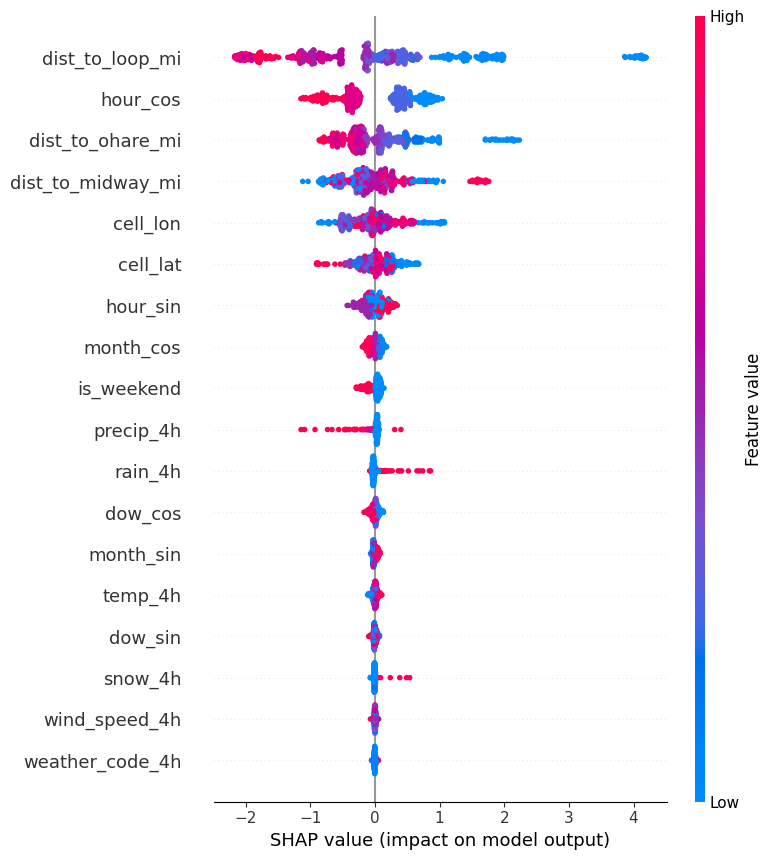

In [12]:
# Feature importance by SHAP values
# SHAP values measure the contribution of each feature to the model's predictions, allowing us to identify which features are most influential in driving demand predictions. This can provide insights into the factors that affect taxi demand and help us understand the model's behavior.


# Step 1: get the scaler and model from the best estimator's pipeline
scaler = best_est.regressor_.named_steps["scaler"]
model  = best_est.regressor_.named_steps["model"]

# Step 2: scale the data
X_dev_scaled = scaler.transform(X_dev)

# Step 3: use KernelExplainer with a small background sample
background   = shap.sample(X_dev_scaled, 200, random_state=RANDOM_STATE)
explainer    = shap.KernelExplainer(model.predict, background)


# Step 4: explain a sample (full X_dev is too slow)
X_explain    = shap.sample(X_dev_scaled, 500, random_state=RANDOM_STATE)
shap_values  = explainer.shap_values(X_explain, silent=True, l1_reg=0)
 
shap.summary_plot(shap_values, X_explain, feature_names=feature_names)  



**SHAP summary plot**
- Y-axis: features ranked by importance (most important at top)
- X-axis: SHAP value - indicates how much this feature pushed the prediction up (+) or down (-)
- Each dot: one prediction from the sample

The graph shows that:
- The most important features are related to spatial unit, especially the **distance** from the hexagon to the busy areas. Low distance to Loop (blue dot) makes the demand increase, which means the hexagon near the busy zones have high demand. It aligns with the business sense.
- The **time features** (`hour_cos`, `hour_sin`) also have the high ranks, which means time of day matters a lot. `is_weekend`: red dot (weekend = 1) slighly negative. It means that weekdays have slightly higher taxi demand overall.
- The **weather features** do not have much contribution to the demand, the SHAP value is nearly 0.

In [13]:
df_include_ypredict = pd.concat([
        test_panel['location_id'].reset_index(drop=True),
        X_test.reset_index(drop=True),
    pd.Series(y_test.values,    name="y_test"),
    pd.Series(y_pred_best,      name="y_pred_best"),
], axis=1)

df_include_ypredict["abs_error"] = (
    df_include_ypredict["y_test"] - df_include_ypredict["y_pred_best"]
).abs()

df_agg = (
    df_include_ypredict
    .groupby("location_id")
    .agg(MAE=("abs_error", "mean"), avg_demand=("y_test", "mean"))
    .reset_index()
)

In [14]:
import h3
from shapely.geometry import Polygon

def h3_to_polygon(cell_id):
    """Return a Shapely Polygon for one H3 cell."""
    # h3.cell_to_boundary returns (lat, lon) pairs — swap to (lon, lat) for shapely
    boundary = h3.cell_to_boundary(cell_id)   # h3 v4
    # if h3 v3: h3.h3_to_geo_boundary(cell_id)
    return Polygon([(lon, lat) for lat, lon in boundary])

df_agg["geometry"] = df_agg["location_id"].apply(h3_to_polygon)

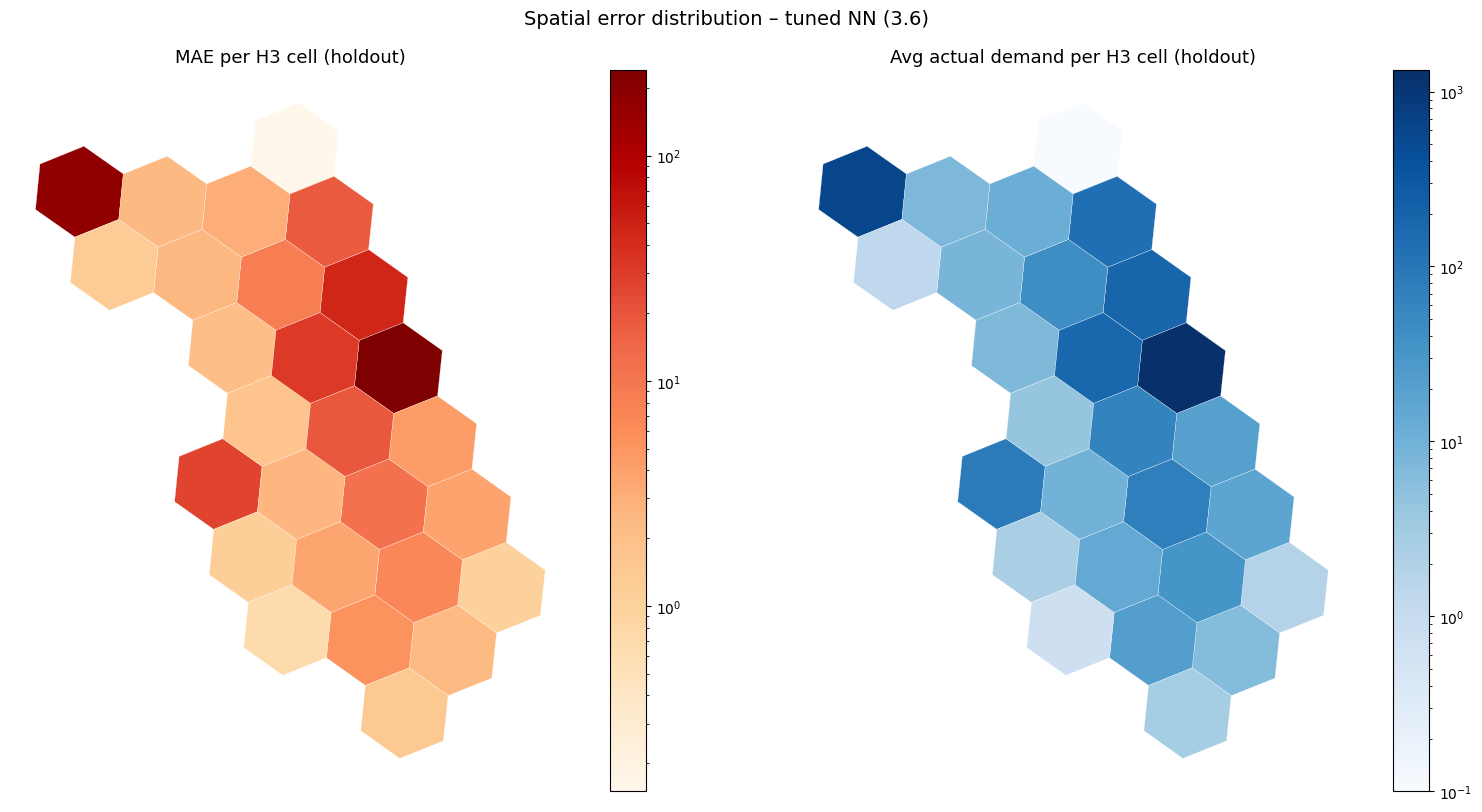

In [15]:
import geopandas as gpd
from matplotlib.colors import LogNorm

gdf = gpd.GeoDataFrame(df_agg, geometry="geometry", crs="EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- left: MAE per cell ---
gdf.plot(
    column     = "MAE",
    cmap       = "OrRd",
    linewidth  = 0.2,
    edgecolor  = "white",
    legend     = True,
    norm       = LogNorm(vmin=gdf["MAE"].clip(lower=0.1).min(),
                         vmax=gdf["MAE"].max()),   # log scale handles the skew
    ax         = axes[0],
)
axes[0].set_title("MAE per H3 cell (holdout)", fontsize=13)
axes[0].set_axis_off()

# --- right: average actual demand per cell (context) ---
gdf.plot(
    column    = "avg_demand",
    cmap      = "Blues",
    linewidth = 0.2,
    edgecolor = "white",
    legend    = True,
    norm      = LogNorm(vmin=gdf["avg_demand"].clip(lower=0.1).min(),
                        vmax=gdf["avg_demand"].max()),
    ax        = axes[1],
)
axes[1].set_title("Avg actual demand per H3 cell (holdout)", fontsize=13)
axes[1].set_axis_off()

plt.suptitle("Spatial error distribution – tuned NN (3.6)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
import joblib
joblib.dump(nn_baseline_est, "../models/nn_baseline.pkl")
joblib.dump(best_est, "../models/nn_tuned.pkl")

['../models/nn_tuned.pkl']

**Hand-off to 3.8.**  
The following variables are consumed by section 3.8:

| Variable | Content |
|---|---|
| `best_est` | Fitted estimator (scaler + base PyTorch model + log1p wrapper) of baseline Neural Network model|
| `metrics_best` | `{"MAE": ..., "RMSE": ..., "R2": ...}` on holdout |
| `y_pred_best` | Predicted demand in test dataset |

### 3.7 Resolution sensitivity

The two final models (best RBF-SVM from 3.4, tuned NN from 3.6) were selected on a single spatial-temporal resolution, H3 r6 x 4h. This section asks how far that choice drives the result, and which resolution actually serves the operational question best. Required outputs:

- both models re-evaluated across **spatial** resolutions (H3 r5 coarser, r6, r7 finer; Community Area) at fixed 4h bins;
- the explicit **census-tract** case the assignment asks for (3.7b);
- both models re-evaluated across **temporal** resolutions (1h, 4h, 8h, 1d) at fixed H3 r6;
- a combined table and a granularity-sparsity visualisation, ending in a recommended resolution for the client.

**Two methodological points before any numbers.**

*Raw error metrics are not comparable across resolutions.* Coarser cells aggregate more trips, so their `demand_count` - and therefore MAE and RMSE - is mechanically larger. An MAE of 30 at r6 and 8 at r7 does not mean r7 is "better"; it means an r7 cell simply holds fewer trips. The cross-resolution comparison is therefore read on two scale-free quantities: **R^2** (variance explained, unit-free) and a **normalised MAE** (`nMAE = MAE / mean demand`). Raw MAE/RMSE are retained only for the within-resolution model-vs-model comparison.

*Resolution is varied, hyperparameters are not.* Re-tuning C/gamma and the network architecture at every resolution would confound the resolution effect with a tuning effect, besides being computationally infeasible. The configurations found in 3.4 and 3.6 are reused unchanged and only re-fitted on each resolution's training split. The hotspot anchors and the scaler are re-fitted per resolution (they are data-derived), exactly as in 3.2.

**Re-aggregation harness.** Each resolution needs its own demand panel, built from the trip-level data with the same aggregate + zero-fill + weather-merge logic as Task 1, so the schema matches `df_agg_r6_4h` exactly. `build_panel_at_resolution` returns the panel and a matching `centroid_fn` - the H3 cell centre for hexagons, and the empirical mean of pickup centroids for Community Area / Census Tract, so no external GeoJSON is required. `run_at_resolution` then reuses the 3.2 protocol end to end: grouped day-holdout, anchors on train only, shared scaler + log1p target, shared `evaluate`.

> **Dependency:** this needs a trip-level export `df_trips_full.parquet`. Task 1's save step (1.6 step 7) currently writes `df_agg_r6_4h` and the weather tables but **not** a trip-level frame, although the 1.6 summary text claims `df_trips_full.parquet` exists. Add it to Task 1 step 7 with the columns listed in the next cell before running 3.7.

One cosmetic caveat: `build_features` (3.1) hard-codes the weather column names with a `_4h` suffix. The harness therefore emits the weather columns under those same names at every temporal resolution, so the values are correct but the suffix is not literal below 4h. Generalising the names would mean editing the shared 3.1 code, which is deliberately left untouched.

**Reliability caveat.** Each resolution refits the models once - the RBF-SVM on a day-subsample, the NN as a single fit of the tuned architecture rather than the CV-selected champion. The per-resolution numbers are therefore *indicative for the resolution trade-off, not a definitive model ranking*: a single NN refit can land 5-10 MAE above its tuned self, so where the two models look close here the authoritative head-to-head is the canonical comparison in 3.8a.

In [20]:
WEATHER_COLS = [
    "temp_4h",
    "rain_4h",
    "snow_4h",
    "precip_4h",
    "wind_speed_4h",
    "weather_code_4h",
]

CHICAGO_CENTER = (41.8781, -87.6298)


def _cyclical(values, period):
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)


def _h3_centroids(cell_ids):
    try:
        from h3 import cell_to_latlng as to_geo
    except ImportError:
        from h3 import h3_to_geo as to_geo

    coords = {c: to_geo(c) for c in pd.unique(cell_ids)}
    lat = cell_ids.map(lambda c: coords[c][0]).astype("float64")
    lon = cell_ids.map(lambda c: coords[c][1]).astype("float64")

    return lat, lon


def _haversine_km(lat1, lon1, lat2, lon2):
    r = 3959.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = np.radians(lat2 - lat1), np.radians(lon2 - lon1)

    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    )

    return 2 * r * np.arcsin(np.sqrt(a))


def detect_hotspot_anchors(train_panel, centroid_fn=_h3_centroids, n_candidates=8):
    tot = train_panel.groupby("location_id")["demand_count"].sum().sort_values(ascending=False)
    cand = list(tot.index[:n_candidates])

    lat, lon = centroid_fn(pd.Series(cand))
    cent = {c: (la, lo) for c, la, lo in zip(cand, lat, lon)}

    chosen = [cand[0]]

    while len(chosen) < 3:
        nxt = max(
            (c for c in cand if c not in chosen),
            key=lambda c: min(_haversine_km(*cent[c], *cent[s]) for s in chosen),
        )
        chosen.append(nxt)

    loop = min(chosen, key=lambda c: _haversine_km(*cent[c], *CHICAGO_CENTER))
    rest = sorted(
        [c for c in chosen if c != loop],
        key=lambda c: cent[c][0],
        reverse=True,
    )

    return {
        "loop": loop,
        "ohare": rest[0],
        "midway": rest[1],
    }


def build_features(panel, anchors, centroid_fn=_h3_centroids):
    d = panel.copy()
    y = d["demand_count"].astype("float64")

    ts = d["timestamp"]

    feats = {}

    feats["hour_sin"], feats["hour_cos"] = _cyclical(ts.dt.hour, 24)
    feats["dow_sin"], feats["dow_cos"] = _cyclical(ts.dt.dayofweek, 7)
    feats["month_sin"], feats["month_cos"] = _cyclical(ts.dt.month - 1, 12)
    feats["is_weekend"] = (ts.dt.dayofweek >= 5).astype("int64")

    lat, lon = centroid_fn(d["location_id"])
    feats["cell_lat"] = lat
    feats["cell_lon"] = lon

    for name, cell in anchors.items():
        a_lat, a_lon = centroid_fn(pd.Series([cell]))
        feats[f"dist_to_{name}_mi"] = _haversine_km(
            lat,
            lon,
            a_lat.iloc[0],
            a_lon.iloc[0],
        )

    X = pd.DataFrame(feats, index=d.index)
    X = pd.concat([X, d[WEATHER_COLS].astype("float64")], axis=1)

    return X, y, list(X.columns)

In [21]:
import time
import joblib

# --- trip-level dependency (see note above) -------------------------------------
TRIPS_PATH = PROCESSED / "df_trips_full.parquet"
TRIPS_COLS = ["trip_id", "trip_start_timestamp", "trip_miles", "trip_seconds", "trip_total",
              "h3_r5", "h3_r6", "h3_r7", "pickup_community_area", "pickup_census_tract",
              "pickup_centroid_latitude", "pickup_centroid_longitude"]
assert TRIPS_PATH.exists(), (
    f"{TRIPS_PATH} not found. Export trip-level data from Task 1 step 7 with columns "
    f"{TRIPS_COLS} before running 3.7.")
trips = pd.read_parquet(TRIPS_PATH, columns=TRIPS_COLS)

# hourly weather is saved by Task 1; aggregate it to any target frequency on the fly
weather_hourly = pd.read_parquet(PROCESSED / "df_weather_hours.parquet")

FREQ = {"time_1h": "h", "time_4h": "4h", "time_8h": "8h", "time_1d": "D"}


def _weather_at(freq, weather_hourly):
    """Aggregate hourly weather to `freq`, named exactly as build_features (3.1) expects."""
    w = weather_hourly.copy()
    w["timestamp"] = w["timestamp_h"].dt.floor(freq)
    return (w.groupby("timestamp")
             .agg(temp_4h=("temp_h", "mean"), rain_4h=("rain_h", "sum"),
                  snow_4h=("snow_h", "sum"), precip_4h=("precip_h", "sum"),
                  wind_speed_4h=("wind_speed_h", "mean"),
                  weather_code_4h=("weather_code_h", "max"))
             .reset_index())


def build_panel_at_resolution(trips, spatial_col, time_col, weather_hourly):
    """Trip-level -> (spatial_col x time bucket) demand panel, zero-filled, weather-merged.
    Mirrors Task 1's aggregate_demand + fill_zeros + weather merge. Returns (panel, centroid_fn)."""
    freq = FREQ[time_col]
    t = trips.dropna(subset=[spatial_col]).copy()
    t["timestamp"] = t["trip_start_timestamp"].dt.floor(freq)

    demand = (t.groupby([spatial_col, "timestamp"], observed=True)
                .agg(demand_count=("trip_id", "count"))
                .reset_index()
                .rename(columns={spatial_col: "location_id"}))

    # explicit zeros over the full (location x time) grid, as in Task 1's fill_zeros
    locs = demand["location_id"].unique()
    times = pd.date_range(demand["timestamp"].min(), demand["timestamp"].max(), freq=freq)
    grid = (pd.MultiIndex.from_product([locs, times], names=["location_id", "timestamp"])
              .to_frame(index=False))
    panel = grid.merge(demand, on=["location_id", "timestamp"], how="left")
    panel["demand_count"] = panel["demand_count"].fillna(0).astype("int64")
    panel = panel.merge(_weather_at(freq, weather_hourly), on="timestamp", how="left")

    # centroid function matching the spatial id type (cell 50 note)
    if spatial_col.startswith("h3_"):
        centroid_fn = _h3_centroids
    else:
        lut = (t.groupby(spatial_col, observed=True)
                 [["pickup_centroid_latitude", "pickup_centroid_longitude"]].mean())

        def centroid_fn(ids, _lut=lut):
            # location_id is a `category` dtype: .map on a categorical Series iterates ALL
            # categories — incl. census tracts with zero trips that are absent from _lut
            # (built with observed=True) -> KeyError. Cast to object so .map sees only the
            # values actually present, while preserving the index for build_features.
            ids = pd.Series(ids).astype(object)
            lat = ids.map(lambda c: _lut.loc[c, "pickup_centroid_latitude"]).astype("float64")
            lon = ids.map(lambda c: _lut.loc[c, "pickup_centroid_longitude"]).astype("float64")
            return lat, lon
    return panel, centroid_fn


# reuse the tuned configurations from 3.4 / 3.6 (read straight off the saved models)
_svr = joblib.load("../models/svm_rbf_best.pkl").regressor_.named_steps["model"]
SVM_PARAMS = {"C": _svr.C, "gamma": _svr.gamma, "epsilon": _svr.epsilon}

_nn = best_est.regressor_.named_steps["model"]
NN_PARAMS = {
    "hidden_sizes": _nn.hidden_sizes,
    "dropout": _nn.dropout,
    "lr": _nn.lr,
    "batch_size": _nn.batch_size,
    "max_epochs": _nn.max_epochs,
    "patience": _nn.patience,
    "val_fraction": _nn.val_fraction,
}

joblib.dump(NN_PARAMS, "../models/nn_best_params.pkl")

print("reused SVM params:", SVM_PARAMS)
print("reused NN  params:", NN_PARAMS)

MAX_TRAIN_ROWS = 30_000   # fixed SVM/NN training budget across all resolutions (fair + tractable)

def _capped_train_index(y, max_rows, rng, n_strata=10):
    """Stratified row cap: split y into equal-size demand strata (by rank, robust to
    the many zeros) and draw equally from each, so high-demand hotspot buckets stay
    represented instead of being drowned out by the zero-demand majority."""
    n = len(y)
    if n <= max_rows:
        return np.arange(n)
    strata = pd.qcut(y.rank(method="first"), q=n_strata, labels=False)
    per = max_rows // n_strata
    idx = []
    for b in range(n_strata):
        pool = np.where(strata == b)[0]
        idx.append(rng.choice(pool, size=min(per, len(pool)), replace=False))
    return np.concatenate(idx)

def run_at_resolution(trips, spatial_col, time_col, weather_hourly, n_candidates=8):
    """Full 3.2 protocol at one (spatial, temporal) resolution. Returns a 2-row metrics frame."""
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.svm import SVR

    panel, centroid_fn = build_panel_at_resolution(trips, spatial_col, time_col, weather_hourly)
    panel["day"] = panel["timestamp"].dt.floor("D")

    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=RANDOM_STATE)
    dev_i, test_i = next(gss.split(panel, groups=panel["day"]))
    dev, test = panel.iloc[dev_i].copy(), panel.iloc[test_i].copy()

    anchors = detect_hotspot_anchors(dev, centroid_fn=centroid_fn, n_candidates=n_candidates)
    Xd, yd, _ = build_features(dev,  anchors, centroid_fn=centroid_fn)
    Xt, yt, _ = build_features(test, anchors, centroid_fn=centroid_fn)

    # fixed stratified training budget so resolutions are compared at EQUAL data volume
    # (else finer grids unfairly get 20x more rows) and the RBF-SVM stays tractable
    rng = np.random.default_rng(RANDOM_STATE)
    idx = _capped_train_index(yd.reset_index(drop=True), MAX_TRAIN_ROWS, rng)
    Xd_fit, yd_fit = Xd.iloc[idx], yd.iloc[idx]

    svm = make_estimator(SVR(kernel="rbf", cache_size=1000, **SVM_PARAMS))
    svm.fit(Xd_fit, yd_fit)
    nn = make_estimator(PytorchRegressor(random_state=RANDOM_STATE, **NN_PARAMS))
    nn.fit(Xd_fit, yd_fit)

    mean_d = float(yt.mean())
    zero_rate = float((panel["demand_count"] == 0).mean())
    rows = []
    for name, est in [("RBF SVM", svm), ("Tuned NN", nn)]:
        mt = evaluate(yt, est.predict(Xt))
        rows.append({"spatial": spatial_col, "temporal": time_col, "model": name,
                     "n_cells": int(panel["location_id"].nunique()), "zero_rate": zero_rate,
                     "mean_demand": mean_d, "MAE": mt["MAE"], "nMAE": mt["MAE"] / mean_d,
                     "RMSE": mt["RMSE"], "R2": mt["R2"]})
    return pd.DataFrame(rows)


reused SVM params: {'C': 10.0, 'gamma': 0.1, 'epsilon': 0.1}
reused NN  params: {'hidden_sizes': (128, 64, 32), 'dropout': 0.1, 'lr': 0.001, 'batch_size': 256, 'max_epochs': 20, 'patience': 15, 'val_fraction': 0.15}


#### 3.7a Spatial sensitivity (temporal fixed at 4h)

Both models are re-fitted and evaluated at H3 r5, r6 and r7, and at Community Area, all at 4-hour bins. `n_candidates` for anchor detection is kept at the default 8 here; it is raised for the finer census-tract grid in 3.7b. The table reports raw MAE/RMSE (within-resolution model comparison) alongside the scale-free `nMAE` and `R2` (cross-resolution comparison).

In [24]:
spatial_results = pd.concat(
    [run_at_resolution(trips, sp, "time_4h", weather_hourly)
     for sp in ["h3_r5", "h3_r6", "h3_r7", "pickup_community_area"]],
    ignore_index=True,
)
spatial_results.round(3)


,spatial,temporal,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,h3_r5,time_4h,RBF SVM,8,0.010,356.725,62.534,0.175,149.828,0.937
1,h3_r5,time_4h,Tuned NN,8,0.010,356.725,69.638,0.195,158.895,0.929
2,h3_r6,time_4h,RBF SVM,27,0.126,105.696,26.432,0.250,100.433,0.911
3,h3_r6,time_4h,Tuned NN,27,0.126,105.696,29.091,0.275,115.259,0.882
4,h3_r7,time_4h,RBF SVM,128,0.492,22.295,16.451,0.738,87.854,0.325
5,h3_r7,time_4h,Tuned NN,128,0.492,22.295,14.423,0.647,72.630,0.539
6,pickup_community_area,time_4h,RBF SVM,77,0.173,37.045,17.319,0.468,79.104,0.694
7,pickup_community_area,time_4h,Tuned NN,77,0.173,37.045,14.948,0.404,62.788,0.807


*Reading.* The granularity-sparsity trade-off is clear: from r5 to r7 the cells grow 8 -> 27 -> 128, mean demand falls **357 -> 106 -> 22**, the zero-rate climbs **1% -> 13% -> 49%**, and `R2` weakens (RBF-SVM **0.94 -> 0.91 -> 0.33**; nMAE 0.18 -> 0.25 -> 0.74). Raw MAE *falls* (62 -> 26 -> 16) purely because the cells hold fewer trips - exactly why the cross-resolution read is on `R2`/nMAE. Community Area (77 cells, `R2` 0.69-0.77) sits between r6 and r7. **Caveat on the model columns:** the per-resolution NN is a single refit and here underperforms its tuned self (its r6 MAE of 35 vs the canonical 25 in 3.8a), so do **not** read the SVM-vs-NN ranking from this table - take it from 3.8a. What this table shows reliably is the SVM's degradation and the sparsity trade-off.

#### 3.7b Census tract as spatial unit

The assignment explicitly asks how performance changes when only census tracts are used as spatial units. Section 1.3 found that `pickup_census_tract` is missing for **55.65%** of trips, so the project uses it nowhere else. It is run here once, as the assignment requires, with the coverage limitation made explicit.

**Should the suppressed tracts be scaled up?** A natural idea is to multiply observed tract demand by `1 / coverage` (about `1 / 0.45`) to recover "true" totals. This is valid only if the missingness is **random** - if the observed tracts were a representative sample of all tracts. They are not. Chicago suppresses the census tract precisely when a trip would be re-identifiable, i.e. when *few* trips occur in that tract during that period. Suppression is therefore conditioned on low demand: it is **missing-not-at-random** and correlated with the target itself. Two consequences follow:

1. The observed 45% over-represents busy tracts and busy hours. A flat `1 / 0.45` factor would inflate exactly the low-demand cells that were hidden, distorting the spatial distribution rather than restoring it.
2. The true coverage factor is not a constant 0.45 but varies by tract and time, so no single multiplier is correct.

We therefore **do not scale**. Census tract is reported as a coverage-limited sensitivity check only: the metrics describe the observable subset, absolute demand is understated, and the panel is not comparable in level to the H3/CA panels. This is consistent with the decision already taken in 1.3. (Had suppression been a fixed random sample - e.g. "every tract reports, but only 45% of rows are logged" - the count-based `1/coverage` rescaling the question hints at would in fact be unbiased; the mechanism here simply is not of that kind.)

In [25]:
ct_coverage = trips["pickup_census_tract"].notna().mean()
print(f"Census-tract coverage: {ct_coverage:.1%} of trips carry a tract id "
      f"(=> absolute demand levels below are understated, not rescaled)")

# finer grid than CA/H3-r6 => raise the anchor candidate pool so secondary hotspots survive
ct_results = run_at_resolution(trips, "pickup_census_tract", "time_4h",
                               weather_hourly, n_candidates=15)
ct_results.round(3)


Census-tract coverage: 45.6% of trips carry a tract id (=> absolute demand levels below are understated, not rescaled)


,spatial,temporal,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,pickup_census_tract,time_4h,RBF SVM,607,0.947,2.106,2.038,0.968,21.037,0.079
1,pickup_census_tract,time_4h,Tuned NN,607,0.947,2.106,1.765,0.838,18.919,0.255


*Reading.* Census tract is the floor: **607 cells, 94.7% of buckets empty, mean demand 2.1**, and `R2` collapses to **0.08 (SVM) / 0.18 (NN)** - essentially no better than predicting the mean. Two effects compound and cannot be separated here. First, the grid is extremely fine, so sparsity alone depresses `R2`, as it already did at r7. Second, only **45.6%** of trips carry a tract and the missing ones are the low-demand ones, so even the observed demand is a biased, deflated picture. The conclusion for the client is that census tract is unsuitable as a primary unit - not because the model is weak, but because the input is both too fine and structurally incomplete in a demand-correlated way. (Rescaling counts by 1/0.456 would shift only the level, not the 95% zero structure or the near-zero `R2`, so it would not rescue predictability even if it were valid.)

#### 3.7c Temporal sensitivity (spatial fixed at H3 r6)

The spatial unit is held at r6 and the time bucket is widened from 1h to 4h, 8h and 1d. Because temporal aggregation is a smoothing operation, the qualitative demand shape is preserved while variance falls; the question is whether the finer 1h target is too sparse to model well and whether 8h/1d over-smooth away the operational signal.

In [26]:
temporal_results = pd.concat(
    [run_at_resolution(trips, "h3_r6", tc, weather_hourly)
     for tc in ["time_1h", "time_4h", "time_8h", "time_1d"]],
    ignore_index=True,
)
temporal_results.round(3)


,spatial,temporal,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,h3_r6,time_1h,RBF SVM,27,0.268,26.424,7.876,0.298,28.822,0.888
1,h3_r6,time_1h,Tuned NN,27,0.268,26.424,7.999,0.303,29.943,0.879
2,h3_r6,time_4h,RBF SVM,27,0.126,105.696,26.432,0.250,100.433,0.911
3,h3_r6,time_4h,Tuned NN,27,0.126,105.696,29.091,0.275,115.259,0.882
4,h3_r6,time_8h,RBF SVM,27,0.078,211.392,46.269,0.219,174.723,0.926
5,h3_r6,time_8h,Tuned NN,27,0.078,211.392,52.625,0.249,207.138,0.896
6,h3_r6,time_1d,RBF SVM,27,0.040,634.177,122.432,0.193,413.329,0.938
7,h3_r6,time_1d,Tuned NN,27,0.040,634.177,157.923,0.249,508.942,0.907


*Reading.* From 1h to 1d the zero-rate falls **26.8% -> 12.6% -> 7.8% -> 4.0%** and `R2` rises (RBF-SVM **0.89 -> 0.91 -> 0.93 -> 0.94**) while raw MAE grows with the bigger counts. But high `R2` at 1d is not a free win: a one-day bucket cannot answer "how many cars at 8am vs 6pm", the tactical question the client actually has. 4h is the practical compromise already chosen in Task 1 - enough temporal grain for shift planning, sparse enough to stay learnable. As in 3.7a the single NN refit is handicapped, so the reliable takeaway here is the monotone smoothing, not the model order (see 3.8a). Temporal binning is a smoothing knob, whereas the spatial unit is a modelling decision - which is why the spatial sweep carries more weight.

#### 3.7d Granularity-sparsity trade-off and recommendation

All runs are stacked into one table and the trade-off is visualised on the scale-free axes: `R2` and `nMAE` against the per-resolution zero-rate. The recommended resolution is the finest one at which `R2` is still acceptable and `nMAE` has not yet run away - i.e. the point where added spatial/temporal detail stops paying for itself in predictability.

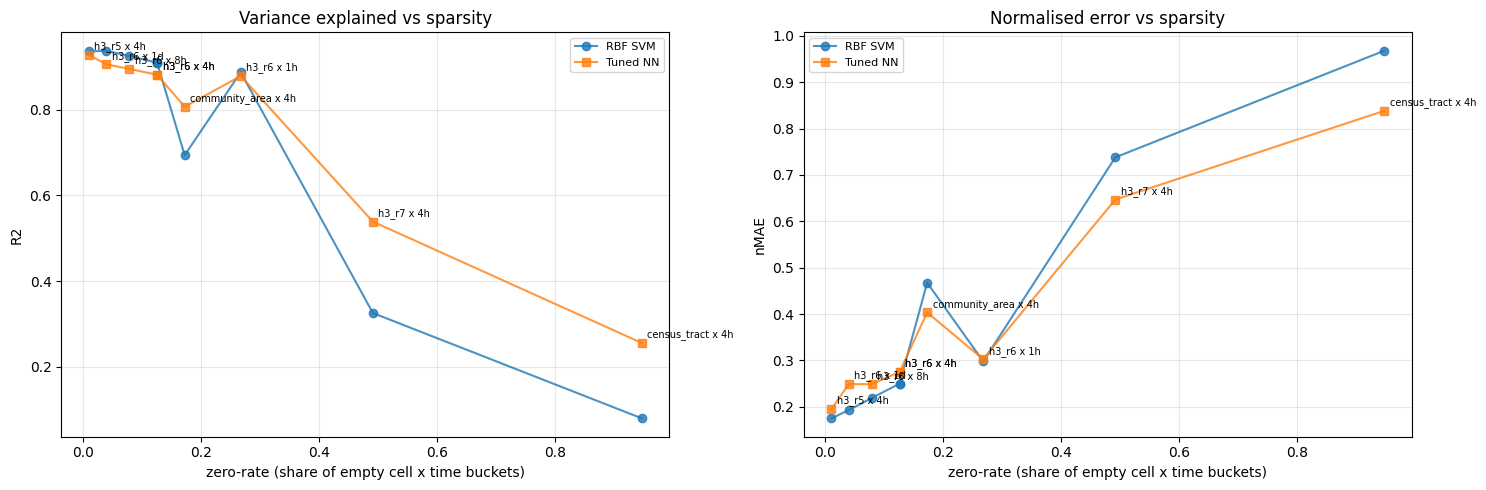

,resolution,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,h3_r5 x 4h,RBF SVM,8,0.010,356.725,62.534,0.175,149.828,0.937
1,h3_r5 x 4h,Tuned NN,8,0.010,356.725,69.638,0.195,158.895,0.929
2,h3_r6 x 4h,RBF SVM,27,0.126,105.696,26.432,0.250,100.433,0.911
3,h3_r6 x 4h,Tuned NN,27,0.126,105.696,29.091,0.275,115.259,0.882
4,h3_r7 x 4h,RBF SVM,128,0.492,22.295,16.451,0.738,87.854,0.325
5,h3_r7 x 4h,Tuned NN,128,0.492,22.295,14.423,0.647,72.630,0.539
6,community_area x 4h,RBF SVM,77,0.173,37.045,17.319,0.468,79.104,0.694
7,community_area x 4h,Tuned NN,77,0.173,37.045,14.948,0.404,62.788,0.807
8,census_tract x 4h,RBF SVM,607,0.947,2.106,2.038,0.968,21.037,0.079
9,census_tract x 4h,Tuned NN,607,0.947,2.106,1.765,0.838,18.919,0.255


In [27]:
res_all = pd.concat([spatial_results, ct_results, temporal_results], ignore_index=True)
res_all["resolution"] = res_all["spatial"].str.replace("pickup_", "", regex=False) + " x " + \
                        res_all["temporal"].str.replace("time_", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model, mk in [("RBF SVM", "o"), ("Tuned NN", "s")]:
    sub = res_all[res_all["model"] == model].sort_values("zero_rate")
    axes[0].plot(sub["zero_rate"], sub["R2"], mk + "-", label=model, alpha=0.8)
    axes[1].plot(sub["zero_rate"], sub["nMAE"], mk + "-", label=model, alpha=0.8)
for ax, ycol, title in [(axes[0], "R2", "Variance explained vs sparsity"),
                        (axes[1], "nMAE", "Normalised error vs sparsity")]:
    for _, r in res_all[res_all["model"] == "Tuned NN"].iterrows():
        ax.annotate(r["resolution"], (r["zero_rate"], r[ycol]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set(xlabel="zero-rate (share of empty cell x time buckets)", ylabel=ycol, title=title)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

res_all[["resolution", "model", "n_cells", "zero_rate", "mean_demand",
         "MAE", "nMAE", "RMSE", "R2"]].round(3)


**Recommendation.** The sweep confirms **H3 r6 x 4h** as the operating point carried into the client recommendation. r5 has the highest `R2` (0.94) but only **8 cells** - operationally meaningless (no neighbourhood detail), its score is a coarse-grid artefact. r7 already pushes the zero-rate to 49% and collapses the SVM (`R2` 0.33); census tract is the floor (`R2` <= 0.18). r6 keeps `R2` around 0.9 with 27 cells and a ~14 mi^2 / 4-hour grain that matches how a fleet is dispatched (neighbourhood-level, shift-level). Community Area (`R2` 0.69-0.77) is the interpretable alternative for reporting. If a coarser, more reliably predictable unit were ever needed, r5 x 4h is the fallback - never a finer grid.

In [28]:
svm_metrics = pd.read_csv("../models/svm_metrics.csv")

nn_metrics = pd.DataFrame([
    {"model": "NN baseline", **metrics_nn_baseline},
    {"model": "NN tuned", **metrics_best},
])

comparison_3_8 = pd.concat([svm_metrics, nn_metrics], ignore_index=True)

comparison_3_8.to_csv("../models/comparison_3_8.csv", index=False)
comparison_3_8

,model,MAE,RMSE,R2
0,Linear SVM,65.563067,203.486047,0.633033
1,RBF SVM,30.831554,118.854508,0.874804
2,NN baseline,25.985520,92.870518,0.923561
3,NN tuned,22.889587,86.456860,0.933754
